# Negative binomial DE with quasi-likelihood dispersion shrinkage

`delnx` implements GPU-accelerated negative binomial GLMs following the [glmGamPoi](https://bioconductor.org/packages/release/bioc/html/glmGamPoi.html) approach with quasi-likelihood dispersion shrinkage for differential expression analysis. The two-step workflow (`nb_fit` + `nb_test`) separates model fitting from hypothesis testing, allowing you to reuse a single fit across multiple contrasts.

In [1]:
import delnx as dx
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# Load example pseudobulk data
adata = sc.read_h5ad("data/GLI3_KO_45d_pseudobulk.h5ad")
adata.obs["GLI3_KO"] = adata.obs["GLI3_KO"].astype(str)  # Ensure string type for design matrix

print(adata)

AnnData object with n_obs × n_vars = 28 × 16199
    obs: 'psbulk_replicate', 'cell_type', 'organoid', 'GLI3_KO', 'psbulk_cells', 'psbulk_counts', 'size_factor'
    var: 'dispersion', 'dispersion_deseq', 'dispersion_mle', 'dispersion_edger', 'mean', 'mean_norm'
    uns: 'log1p'
    layers: 'counts', 'psbulk_props'


## Fit the model

`nb_fit` handles everything in one call: size factor estimation, dispersion MLE with Cox-Reid bias adjustment, quasi-likelihood shrinkage, and coefficient fitting via IRLS.

In [2]:
# Fit negative binomial GLMs with quasi-likelihood dispersion shrinkage
fit = dx.tl.nb_fit(adata, condition_key="GLI3_KO", reference="True")

print(f"Coefficients: {fit.design_column_names}")
print(f"Genes fitted: {len(fit.overdispersions)}")
print(f"Dispersion range: {fit.overdispersions.min():.4f} - {fit.overdispersions.max():.2f}")

INFO     Fitting 16199 genes with 2 coefficient(s)                                                                 


Fitting GLMs:   0%|          | 0/32 [00:00<?, ?it/s]

Fitting GLMs:   3%|▎         | 1/32 [00:03<02:03,  3.97s/it]

Fitting GLMs:  12%|█▎        | 4/32 [00:04<00:21,  1.28it/s]

Fitting GLMs:  22%|██▏       | 7/32 [00:04<00:09,  2.62it/s]

...

Fitting GLMs:  88%|████████▊ | 28/32 [00:04<00:00, 18.71it/s]

Fitting GLMs:  97%|█████████▋| 31/32 [00:05<00:00, 20.67it/s]

Fitting GLMs: 100%|██████████| 32/32 [00:08<00:00,  3.71it/s]

INFO     Applying quasi-likelihood shrinkage                                                                       


Coefficients: ['Intercept', 'GLI3_KO[T.False]']
Genes fitted: 16199
Dispersion range: nan - nan


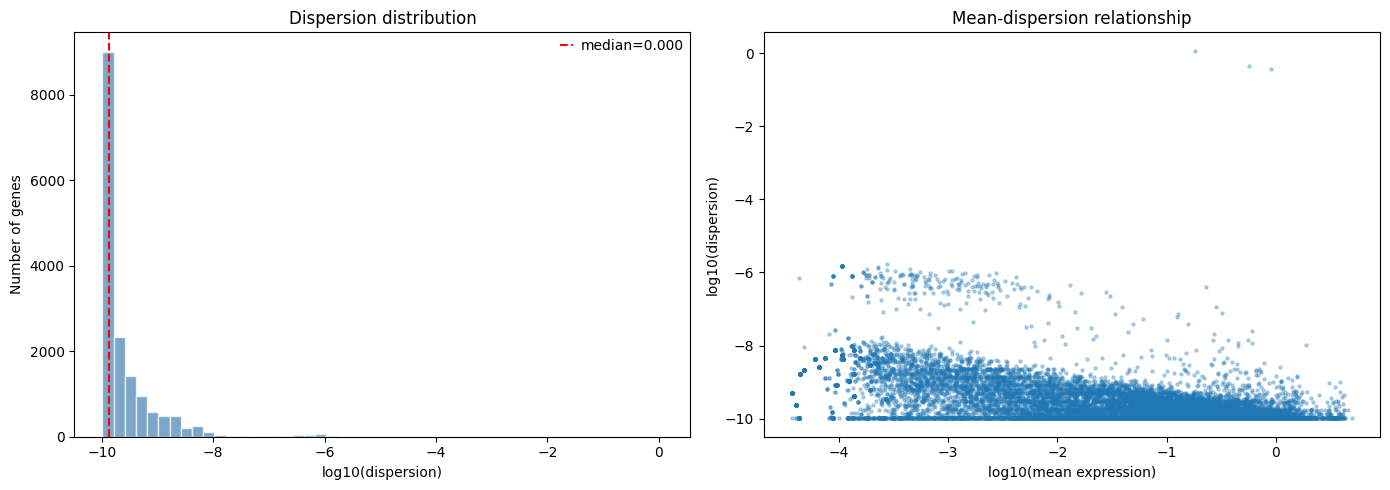

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: dispersion distribution
valid_disp = fit.overdispersions[fit.overdispersions > 0]
axes[0].hist(np.log10(valid_disp), bins=50, color="steelblue", alpha=0.7, edgecolor="white")
axes[0].set_xlabel("log10(dispersion)")
axes[0].set_ylabel("Number of genes")
axes[0].set_title("Dispersion distribution")
axes[0].axvline(np.log10(np.median(valid_disp)), color="red", linestyle="--", label=f"median={np.median(valid_disp):.3f}")
axes[0].legend()

# Right: mean-dispersion relationship
gene_means = np.asarray(adata.X).mean(axis=0) if hasattr(adata.X, 'toarray') else adata.X.mean(axis=0)
mask = (gene_means > 0) & (fit.overdispersions > 0)
axes[1].scatter(np.log10(gene_means[mask]), np.log10(fit.overdispersions[mask]), s=5, alpha=0.3)
axes[1].set_xlabel("log10(mean expression)")
axes[1].set_ylabel("log10(dispersion)")
axes[1].set_title("Mean-dispersion relationship")

plt.tight_layout()
plt.show()
plt.close()

The **left panel** shows the distribution of MLE dispersions across genes. Most genes cluster around the median, with a long tail of highly variable genes.

The **right panel** shows the characteristic mean-dispersion relationship: lowly expressed genes tend to have higher dispersion, while highly expressed genes converge toward lower dispersion values.

## Test for differential expression

Now we test for DE using the fitted model. `nb_test` uses a quasi-likelihood F-test, which accounts for the uncertainty in dispersion estimation.

In [4]:
# Test for differential expression
de_results = dx.tl.nb_test(adata, fit, contrast="GLI3_KO[T.False]")

print(de_results)

       feature    log2fc      coef       stat      pval  padj
0       NKX2-1 -8.103226 -5.616728  12.595398  0.000404   1.0
1        SFTA3 -8.264163 -5.728281   9.793341  0.001801   1.0
2         LHX8 -7.432299 -5.151677   6.751905  0.009499   1.0
3      NEUROD6  7.950968  5.511191   4.765013  0.029270   1.0
4          PTN  1.130485  0.783593   4.733403  0.029810   1.0
...        ...       ...       ...        ...       ...   ...
16194     GJB3       NaN       NaN        NaN       NaN   1.0
16195    CCL16       NaN       NaN        NaN       NaN   1.0
16196     CCR1       NaN       NaN        NaN       NaN   1.0
16197    PLET1       NaN       NaN        NaN       NaN   1.0
16198     ORM2       NaN       NaN        NaN       NaN   1.0

[16199 rows x 6 columns]


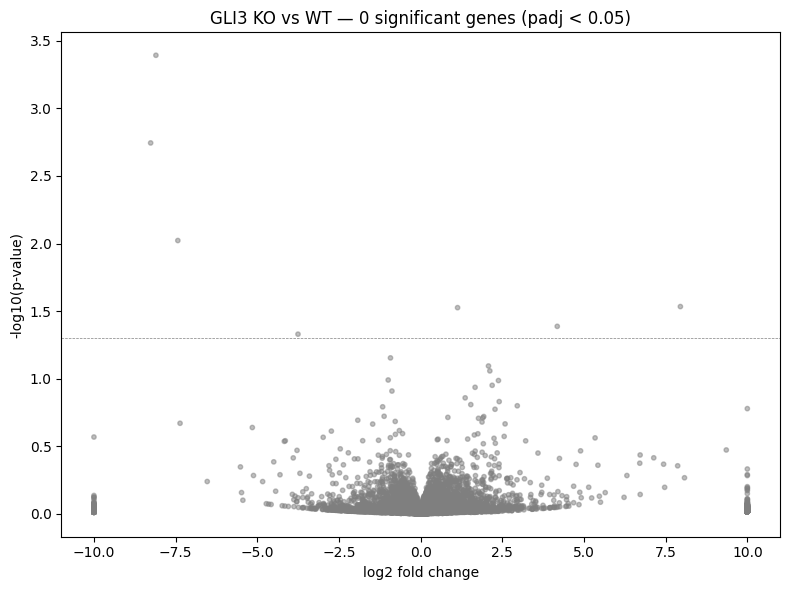

In [5]:
# Volcano plot
fig, ax = plt.subplots(figsize=(8, 6))

sig = de_results["padj"] < 0.05
colors = np.where(sig, "tab:red", "tab:grey")

ax.scatter(de_results["log2fc"], -np.log10(de_results["pval"]), c=colors, s=10, alpha=0.5)
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_xlabel("log2 fold change")
ax.set_ylabel("-log10(p-value)")
ax.set_title(f"GLI3 KO vs WT — {sig.sum()} significant genes (padj < 0.05)")

plt.tight_layout()
plt.show()
plt.close()